In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style="whitegrid")

print("Kütüphaneler yüklendi ")

Kütüphaneler yüklendi 


In [14]:
from google.colab import files
uploaded = files.upload()

Saving final_analiz_veriseti.csv to final_analiz_veriseti (1).csv


In [16]:
print("Satır x Sütun:", df.shape)

Satır x Sütun: (2434, 12)


In [17]:
df.head()

,user_id,app_name,screen_time_min,category,date,age,gender,source,birim_katsayı,Toplam_GB_Harcama,su_katsayi,Toplam_Su_Harcama_Litre
0,1034,instagram,25.19,Social,2024-01-01,NaN,NaN,screen_time_app_usage,0.72,0.30228,0.222,0.067106
1,1063,instagram,4.37,Social,2024-01-01,NaN,NaN,screen_time_app_usage,0.72,0.05244,0.222,0.011642
2,1060,instagram,58.42,Social,2024-01-01,NaN,NaN,screen_time_app_usage,0.72,0.70104,0.222,0.155631
3,1016,snapchat,5.08,Social,2024-01-01,NaN,NaN,screen_time_app_usage,0.60,0.05080,0.037,0.001880
4,1060,instagram,36.16,Social,2024-01-01,NaN,NaN,screen_time_app_usage,0.72,0.43392,0.222,0.096330


In [18]:
df.tail()

,user_id,app_name,screen_time_min,category,date,age,gender,source,birim_katsayı,Toplam_GB_Harcama,su_katsayi,Toplam_Su_Harcama_Litre
2429,U_996,linkedin,479.0,Social,NaN,NaN,NaN,odev2,0.10,0.798333,0.029,0.023152
2430,U_997,instagram,499.0,Social,NaN,NaN,NaN,odev2,0.72,5.988000,0.222,1.329336
2431,U_998,facebook,318.0,Social,NaN,NaN,NaN,odev2,0.30,1.590000,0.222,0.352980
2432,U_999,tiktok,305.0,Social,NaN,NaN,NaN,odev2,1.28,6.506667,0.090,0.585600
2433,U_1000,pinterest,115.0,Social,NaN,NaN,NaN,odev2,0.15,0.287500,0.011,0.003162


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2434 entries, 0 to 2433
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  2434 non-null   object 
 1   app_name                 2434 non-null   object 
 2   screen_time_min          2434 non-null   float64
 3   category                 2434 non-null   object 
 4   date                     1342 non-null   object 
 5   age                      92 non-null     float64
 6   gender                   91 non-null     object 
 7   source                   2434 non-null   object 
 8   birim_katsayı            2434 non-null   float64
 9   Toplam_GB_Harcama        2434 non-null   float64
 10  su_katsayi               2434 non-null   float64
 11  Toplam_Su_Harcama_Litre  2434 non-null   float64
dtypes: float64(6), object(6)
memory usage: 228.3+ KB


In [20]:
print("eksik değerler")
print(df.isnull().sum())

eksik değerler
user_id                       0
app_name                      0
screen_time_min               0
category                      0
date                       1092
age                        2342
gender                     2343
source                        0
birim_katsayı                 0
Toplam_GB_Harcama             0
su_katsayi                    0
Toplam_Su_Harcama_Litre       0
dtype: int64


In [21]:
print("eksik değer yüzdesi")
eksik_yuzde = (df.isnull().sum() / len(df)) * 100
print(eksik_yuzde.round(2))

eksik değer yüzdesi
user_id                     0.00
app_name                    0.00
screen_time_min             0.00
category                    0.00
date                       44.86
age                        96.22
gender                     96.26
source                      0.00
birim_katsayı               0.00
Toplam_GB_Harcama           0.00
su_katsayi                  0.00
Toplam_Su_Harcama_Litre     0.00
dtype: float64


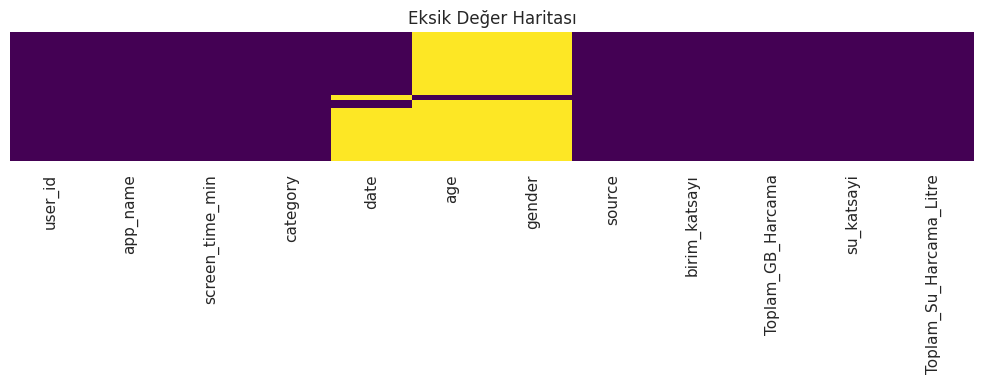

In [22]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Eksik Değer Haritası")
plt.tight_layout()
plt.show()

In [23]:
print("Temizleme öncesi:", df.shape)

df['gender'] = df['gender'].fillna('Unknown')
df['age'] = df['age'].fillna(df['age'].median())

df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Temizleme sonrası:", df.shape)
print("\nEksik değerler kaldı mı?")
print(df.isnull().sum())

Temizleme öncesi: (2434, 12)
Temizleme sonrası: (2434, 12)

Eksik değerler kaldı mı?
user_id                       0
app_name                      0
screen_time_min               0
category                      0
date                       1092
age                           0
gender                        0
source                        0
birim_katsayı                 0
Toplam_GB_Harcama             0
su_katsayi                    0
Toplam_Su_Harcama_Litre       0
dtype: int64


In [24]:
df.describe()

,screen_time_min,date,age,birim_katsayı,Toplam_GB_Harcama,su_katsayi,Toplam_Su_Harcama_Litre
count,2434.000000,1342,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000
mean,122.640078,2024-03-06 16:58:18.062593280,27.012736,0.818587,1.160672,0.109427,0.118619
min,0.010000,2024-01-01 00:00:00,21.000000,0.100000,0.000150,0.011000,0.000019
25%,18.742500,2024-01-26 00:00:00,27.000000,0.200000,0.132125,0.037000,0.008276
50%,52.990000,2024-02-21 00:00:00,27.000000,0.600000,0.430250,0.066000,0.026653
75%,194.000000,2024-03-17 00:00:00,27.000000,0.720000,1.331125,0.222000,0.099631
max,500.000000,2024-08-30 00:00:00,35.000000,3.000000,10.624000,0.222000,1.329336
std,142.678070,NaN,0.720382,0.925260,1.738511,0.085727,0.226071


In [25]:
print("uygulama dağılımı")
print(df['app_name'].value_counts())

uygulama dağılımı
app_name
facebook     347
twitter      333
snapchat     324
instagram    322
tiktok       269
linkedin     187
whatsapp     186
netflix      184
youtube      142
pinterest    140
Name: count, dtype: int64


In [26]:
print("kategori dağılımı")
print(df['category'].value_counts())

kategori dağılımı
category
Social           2005
Entertainment     429
Name: count, dtype: int64


In [27]:
print("cinsiyet dağılımı")
print(df['gender'].value_counts())

cinsiyet dağılımı
gender
Unknown       2343
Male            37
Non-binary      29
Female          25
Name: count, dtype: int64


In [28]:
print("su tüketimi")
print(f"Ortalama : {df['Toplam_Su_Harcama_Litre'].mean():.4f} litre")
print(f"Medyan   : {df['Toplam_Su_Harcama_Litre'].median():.4f} litre")
print(f"Maksimum : {df['Toplam_Su_Harcama_Litre'].max():.4f} litre")
print(f"Minimum  : {df['Toplam_Su_Harcama_Litre'].min():.4f} litre")
print(f"Toplam   : {df['Toplam_Su_Harcama_Litre'].sum():.2f} litre")

su tüketimi
Ortalama : 0.1186 litre
Medyan   : 0.0267 litre
Maksimum : 1.3293 litre
Minimum  : 0.0000 litre
Toplam   : 288.72 litre


/tmp/ipykernel_577/2994135416.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='app_name',


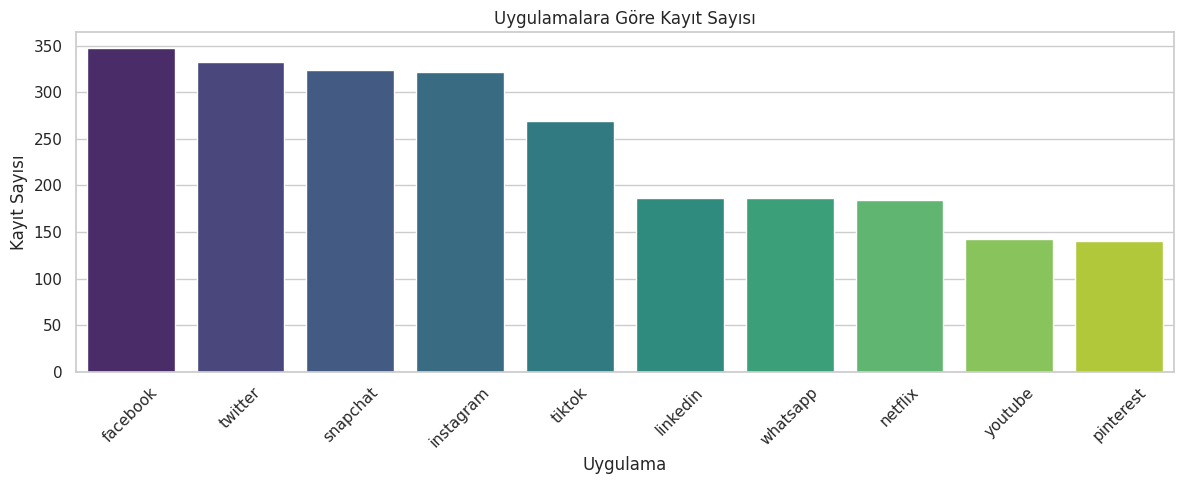

In [29]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='app_name',
              order=df['app_name'].value_counts().index,
              palette='viridis')
plt.title("Uygulamalara Göre Kayıt Sayısı")
plt.xlabel("Uygulama")
plt.ylabel("Kayıt Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

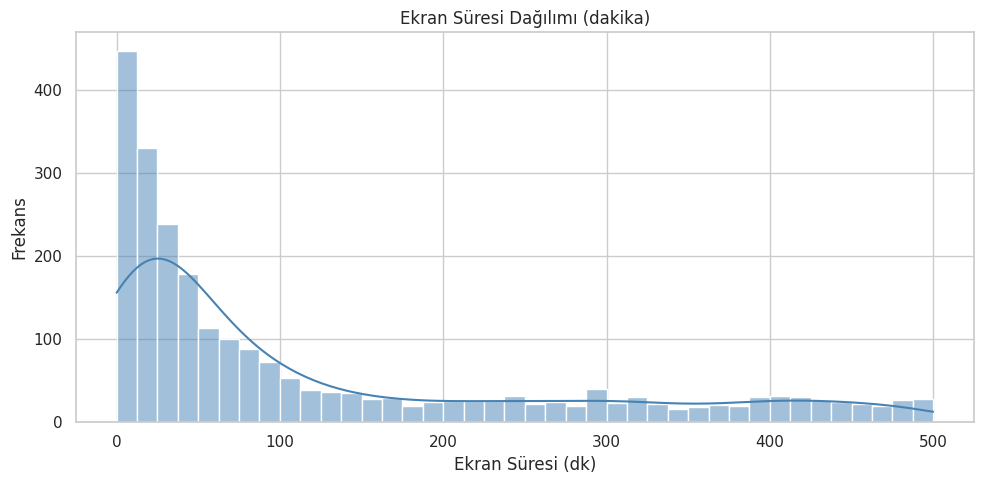

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(df['screen_time_min'], bins=40, kde=True, color='steelblue')
plt.title("Ekran Süresi Dağılımı (dakika)")
plt.xlabel("Ekran Süresi (dk)")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

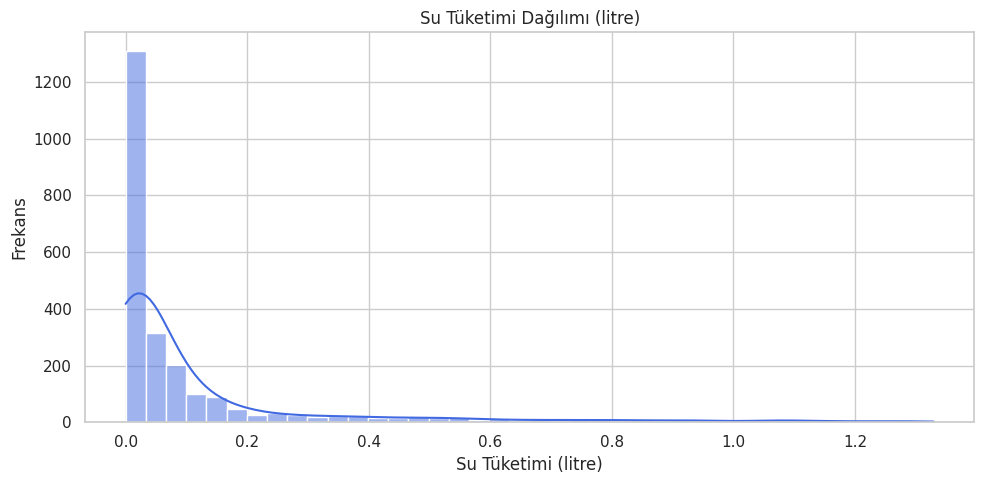

In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Toplam_Su_Harcama_Litre'], bins=40, kde=True, color='royalblue')
plt.title("Su Tüketimi Dağılımı (litre)")
plt.xlabel("Su Tüketimi (litre)")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

/tmp/ipykernel_577/676208554.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_su.index, y=platform_su.values, palette='Blues_r')


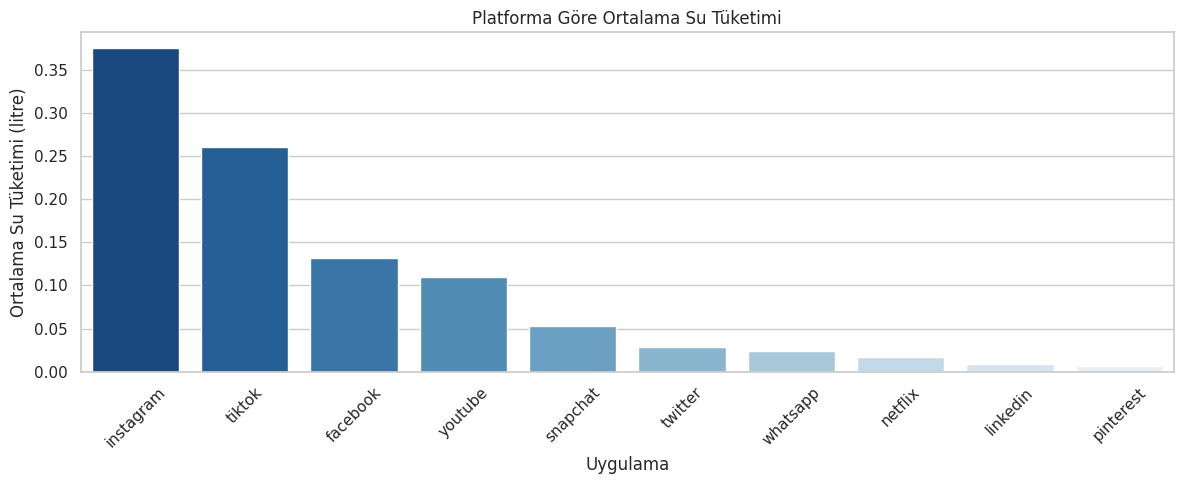

In [32]:
platform_su = df.groupby('app_name')['Toplam_Su_Harcama_Litre'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=platform_su.index, y=platform_su.values, palette='Blues_r')
plt.title("Platforma Göre Ortalama Su Tüketimi")
plt.xlabel("Uygulama")
plt.ylabel("Ortalama Su Tüketimi (litre)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_577/1692614563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='app_name', y='screen_time_min', palette='Set2')


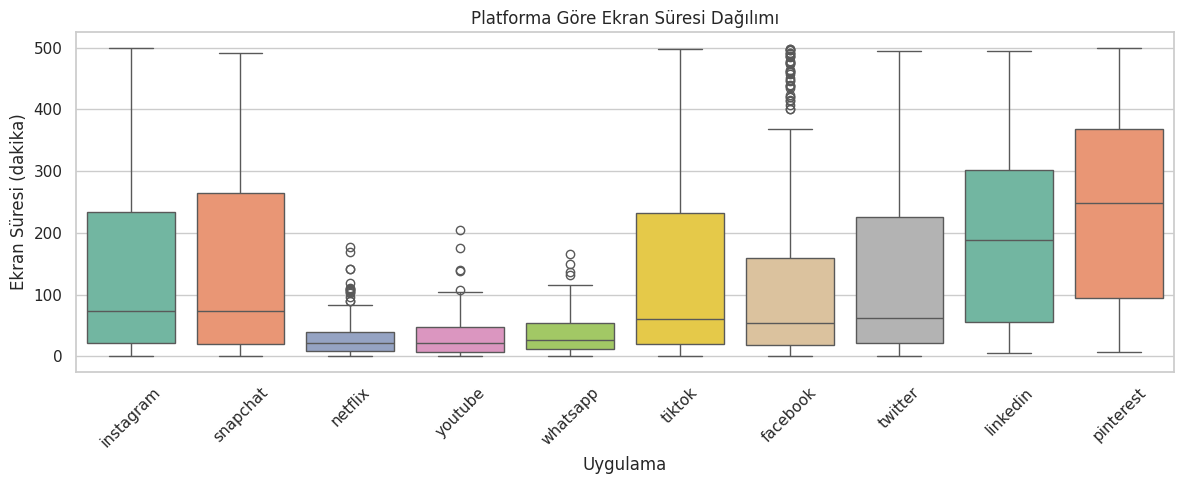

In [33]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='app_name', y='screen_time_min', palette='Set2')
plt.title("Platforma Göre Ekran Süresi Dağılımı")
plt.xlabel("Uygulama")
plt.ylabel("Ekran Süresi (dakika)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_577/188013768.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='app_name', y='Toplam_Su_Harcama_Litre', palette='Set3')


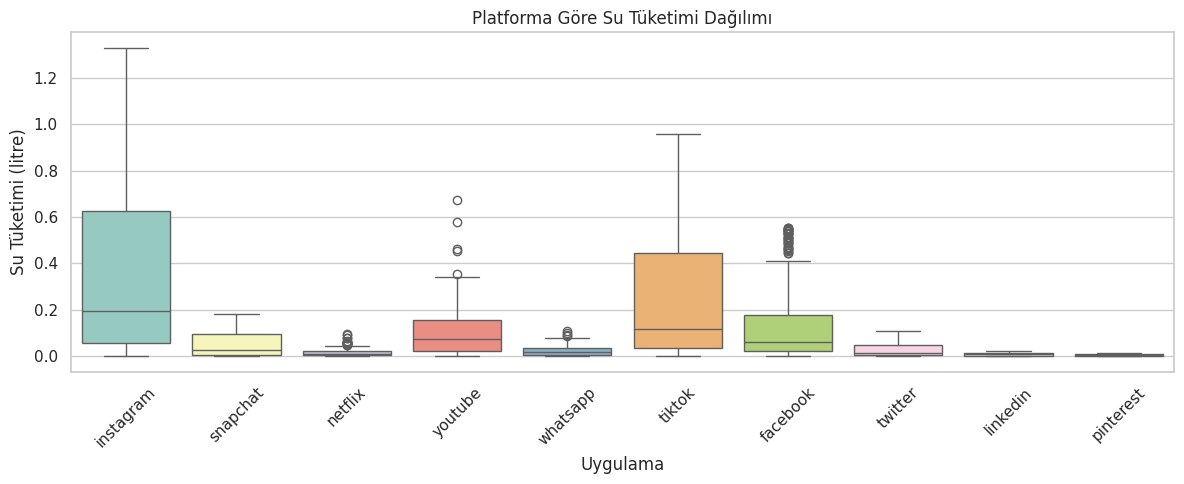

In [34]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='app_name', y='Toplam_Su_Harcama_Litre', palette='Set3')
plt.title("Platforma Göre Su Tüketimi Dağılımı")
plt.xlabel("Uygulama")
plt.ylabel("Su Tüketimi (litre)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

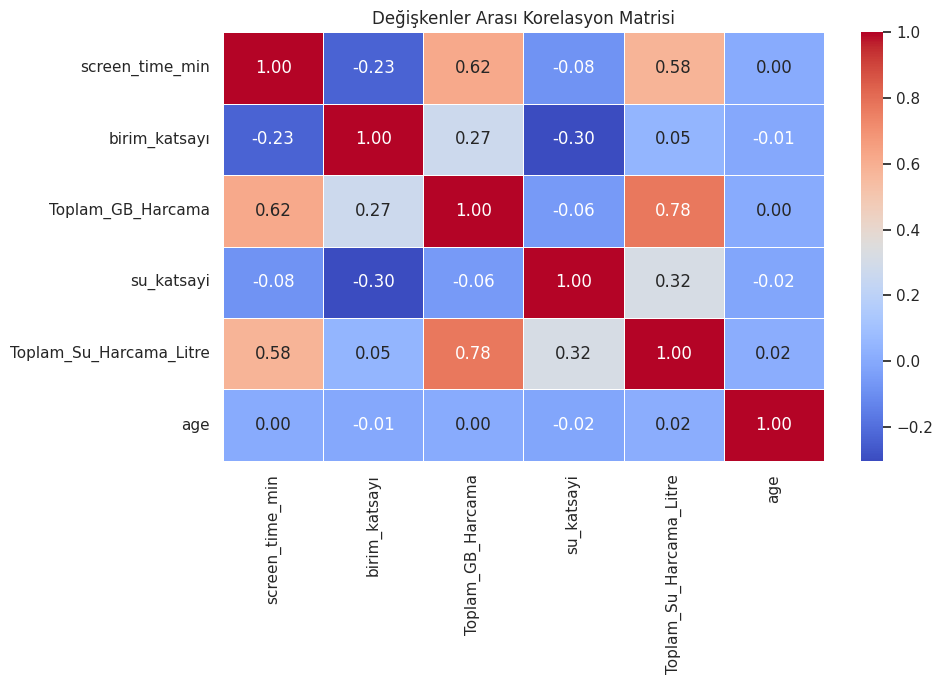

In [35]:
sayisal = df[['screen_time_min', 'birim_katsayı', 'Toplam_GB_Harcama',
              'su_katsayi', 'Toplam_Su_Harcama_Litre', 'age']]

plt.figure(figsize=(10, 7))
sns.heatmap(sayisal.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Değişkenler Arası Korelasyon Matrisi")
plt.tight_layout()
plt.show()

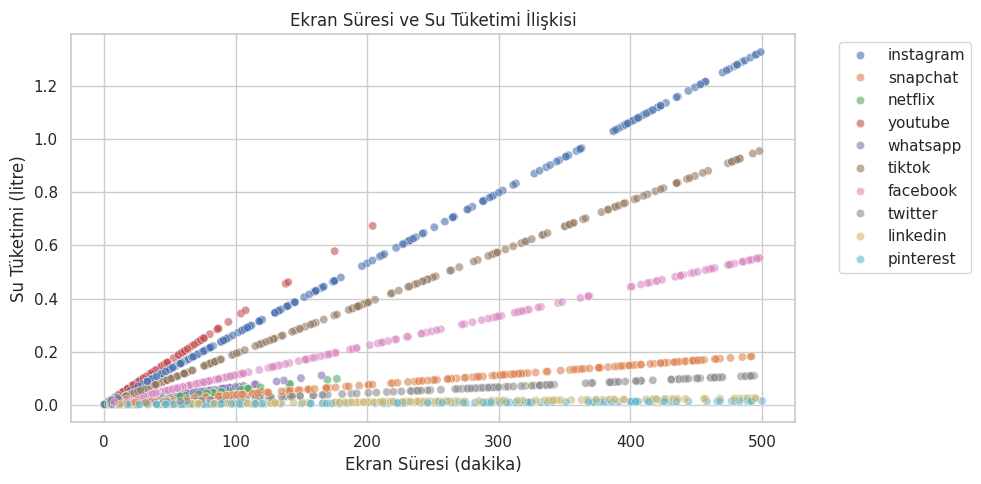

In [36]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='screen_time_min', y='Toplam_Su_Harcama_Litre',
                hue='app_name', alpha=0.6)
plt.title("Ekran Süresi ve Su Tüketimi İlişkisi")
plt.xlabel("Ekran Süresi (dakika)")
plt.ylabel("Su Tüketimi (litre)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

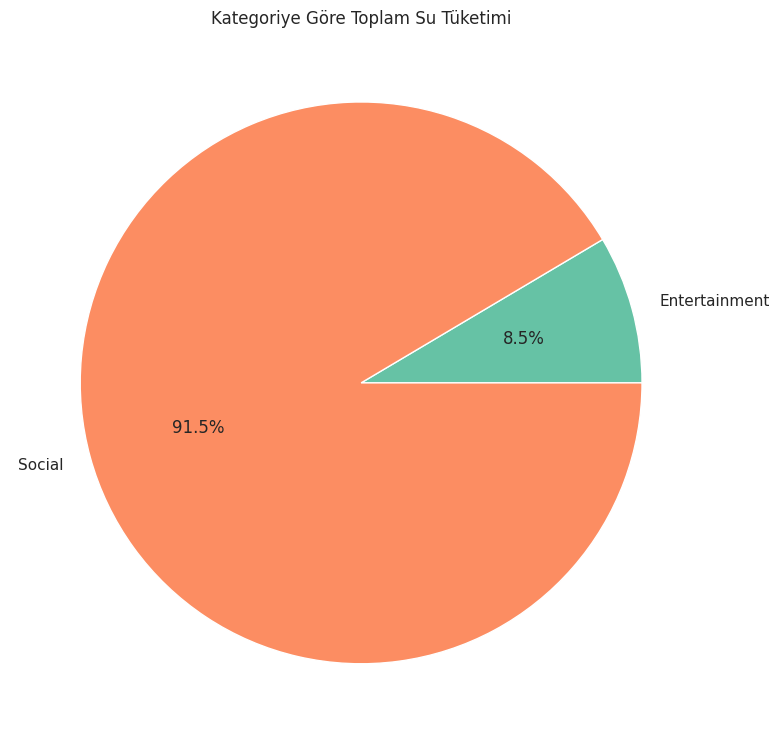

In [37]:
kategori_su = df.groupby('category')['Toplam_Su_Harcama_Litre'].sum()

plt.figure(figsize=(8, 8))
plt.pie(kategori_su.values, labels=kategori_su.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2'))
plt.title("Kategoriye Göre Toplam Su Tüketimi")
plt.tight_layout()
plt.show()

In [39]:
platform_ozet = df.groupby('app_name').agg(
    kayit_sayisi=('app_name', 'count'),
    ort_ekran_suresi=('screen_time_min', 'mean'),
    ort_su_tuketimi=('Toplam_Su_Harcama_Litre', 'mean'),
    toplam_su=('Toplam_Su_Harcama_Litre', 'sum'),
    maks_su=('Toplam_Su_Harcama_Litre', 'max')
).round(4).sort_values('ort_su_tuketimi', ascending=False)

print("platform bazlı özet")
print(platform_ozet)

platform bazlı özet
           kayit_sayisi  ort_ekran_suresi  ort_su_tuketimi  toplam_su  maks_su
app_name                                                                      
instagram           322          140.5883           0.3745   120.5978   1.3293
tiktok              269          135.4010           0.2600    69.9319   0.9562
facebook            347          118.4452           0.1315    45.6215   0.5528
youtube             142           33.3845           0.1102    15.6440   0.6738
snapchat            324          142.5669           0.0527    17.0909   0.1820
twitter             333          129.7672           0.0285     9.5067   0.1087
whatsapp            186           35.9151           0.0239     4.4490   0.1101
netflix             184           31.9249           0.0176     3.2308   0.0973
linkedin            187          192.2193           0.0093     1.7373   0.0239
pinterest           140          236.2071           0.0065     0.9094   0.0137


In [40]:
korelasyon = df['screen_time_min'].corr(df['Toplam_Su_Harcama_Litre'])
print(f"Ekran süresi - Su tüketimi korelasyonu: {korelasyon:.4f}")

if korelasyon > 0.8:
    print("Çok güçlü pozitif ilişki: Ekran süresi arttıkça su tüketimi artıyor.")
elif korelasyon > 0.5:
    print("Orta güçlü ilişki var.")
else:
    print("Zayıf ilişki — platform tipi su tüketimini daha çok etkiliyor.")

Ekran süresi - Su tüketimi korelasyonu: 0.5817
Orta güçlü ilişki var.


In [41]:
print("proje hedefleriyle bağlantı")
print()
print("SDG 6 — Temiz Su ve Sanitasyon:")
print(f"  Veri setindeki toplam dijital su ayak izi: {df['Toplam_Su_Harcama_Litre'].sum():.2f} litre")
print(f"  Kişi başı ortalama günlük su tüketimi: {df.groupby('user_id')['Toplam_Su_Harcama_Litre'].sum().mean():.4f} litre")
print()
print("SDG 13 — İklim Eylemi:")
en_kotu = platform_ozet['ort_su_tuketimi'].idxmax()
en_iyi  = platform_ozet['ort_su_tuketimi'].idxmin()
print(f"  En yüksek su tüketen platform: {en_kotu}")
print(f"  En düşük su tüketen platform : {en_iyi}")
print()
print("Kullanıcılar daha az video içeriği izleyerek")
print("  dijital su ayak izlerini önemli ölçüde azaltabilir.")

proje hedefleriyle bağlantı

SDG 6 — Temiz Su ve Sanitasyon:
  Veri setindeki toplam dijital su ayak izi: 288.72 litre
  Kişi başı ortalama günlük su tüketimi: 0.2426 litre

SDG 13 — İklim Eylemi:
  En yüksek su tüketen platform: instagram
  En düşük su tüketen platform : pinterest

Kullanıcılar daha az video içeriği izleyerek
  dijital su ayak izlerini önemli ölçüde azaltabilir.


In [42]:
def su_seviyesi(litre):
    if litre > 0.3:
        return 'Yüksek'
    elif litre > 0.05:
        return 'Orta'
    else:
        return 'Düşük'

df['su_seviyesi'] = df['Toplam_Su_Harcama_Litre'].apply(su_seviyesi)

print("su tüketim seviyesi")
print(df['su_seviyesi'].value_counts())

su tüketim seviyesi
su_seviyesi
Düşük     1485
Orta       662
Yüksek     287
Name: count, dtype: int64


/tmp/ipykernel_577/547703376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='su_seviyesi',


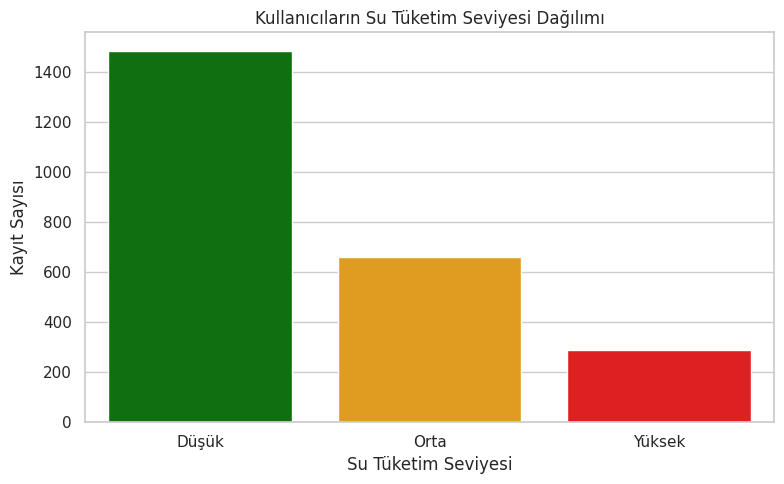

In [43]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='su_seviyesi',
              order=['Düşük', 'Orta', 'Yüksek'],
              palette=['green', 'orange', 'red'])
plt.title("Kullanıcıların Su Tüketim Seviyesi Dağılımı")
plt.xlabel("Su Tüketim Seviyesi")
plt.ylabel("Kayıt Sayısı")
plt.tight_layout()
plt.show()

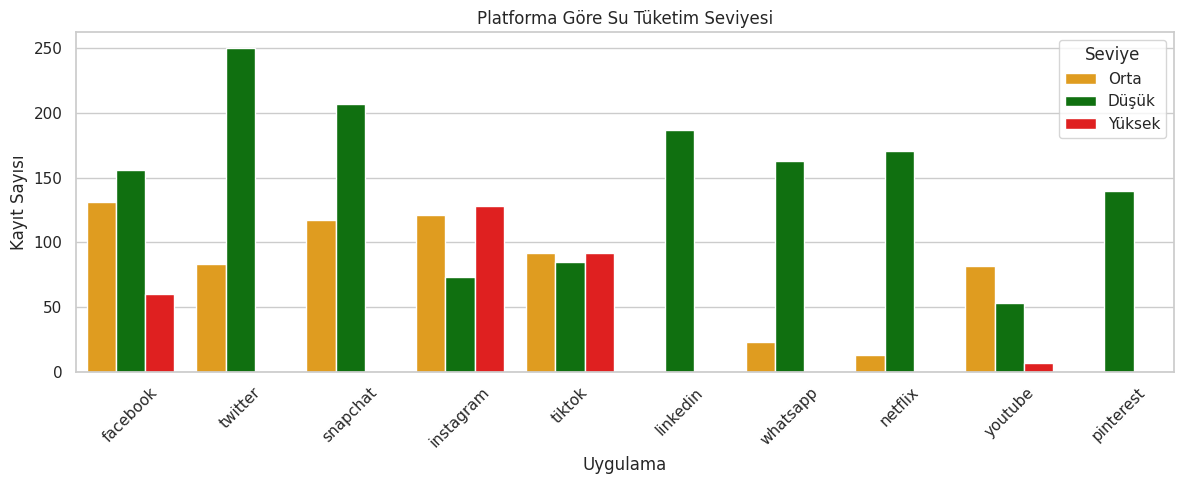

In [44]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='app_name', hue='su_seviyesi',
              order=df['app_name'].value_counts().index,
              palette={'Düşük': 'green', 'Orta': 'orange', 'Yüksek': 'red'})
plt.title("Platforma Göre Su Tüketim Seviyesi")
plt.xlabel("Uygulama")
plt.ylabel("Kayıt Sayısı")
plt.xticks(rotation=45)
plt.legend(title="Seviye")
plt.tight_layout()
plt.show()